### Pemisahan Fitur ($X$) dan Label ($y$)

Memisahkan kolom matriks TF-IDF (sebagai variabel prediktor $X$) dari kolom id dan label (sebagai variabel target $y$).

In [4]:
import pandas as pd

# Load data matriks TF-IDF jika belum ada di memory
if 'df_tfidf' not in locals():
    df_tfidf = pd.read_csv('detik_tfidf_matrix.csv')

# 1. Pisahkan Fitur (X) dan Target (y)
X = df_tfidf.drop(columns=['id', 'label'])
y = df_tfidf['label']

print("=== PEMISAHAN FITUR DAN LABEL ===")
print(f"• Dimensi Fitur (X) : {X.shape} ({X.shape[0]} artikel, {X.shape[1]} kata unik)")
print(f"• Jumlah Label (y)  : {y.shape[0]} data (1 = Sport, 0 = Finance)")

=== PEMISAHAN FITUR DAN LABEL ===
• Dimensi Fitur (X) : (200, 5305) (200 artikel, 5305 kata unik)
• Jumlah Label (y)  : 200 data (1 = Sport, 0 = Finance)


### Analisis Explained Variance Ratio (Menentukan Jumlah Komponen)

Melihat berapa banyak informasi (varians) dari ribuan kata unik yang berhasil dipertahankan saat dikompresi menjadi sejumlah komponen PCA.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

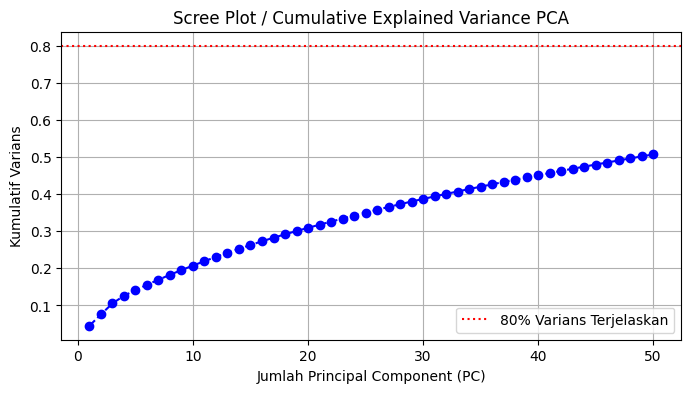

• Varians terjelaskan oleh 2 PC pertama: 7.59%


In [4]:
# 1. Fit PCA dengan seluruh/banyak komponen awal
pca_full = PCA(n_components=50)
pca_full.fit(X)

# 2. Hitung kumulatif varians
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Visualisasi Grafik Cumulative Explained Variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Varians Terjelaskan')
plt.title('Scree Plot / Cumulative Explained Variance PCA')
plt.xlabel('Jumlah Principal Component (PC)')
plt.ylabel('Kumulatif Varians')
plt.legend()
plt.grid(True)
plt.show()

print(f"• Varians terjelaskan oleh 2 PC pertama: {cumulative_variance[1]*100:.2f}%")

### Aplikasi PCA (Reduksi menjadi 2 Komponen Utama)

Mengompresi ribuan kolom kata unik menjadi 2 Utama (PC1 & PC2) agar dapat dipetakan secara visual dalam koordinat 2D.

In [17]:
# 1. Inisialisasi PCA (Contoh: mempertahankan 85% varians)
pca_2d = PCA(n_components=0.85, random_state=42)

# 2. Fit & Transform pada data TF-IDF
X_pca = pca_2d.fit_transform(X)

print("=== HASIL REDUKSI DIMENSI PCA ===")
print(f"• Dimensi Awal  : {X.shape}")
print(f"• Dimensi Akhir : {X_pca.shape} ({X_pca.shape[1]} Komponen Utama)")
print(f"• Total Varians Terjelaskan : {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

=== HASIL REDUKSI DIMENSI PCA ===
• Dimensi Awal  : (200, 5305)
• Dimensi Akhir : (200, 127) (127 Komponen Utama)
• Total Varians Terjelaskan : 85.28%


### Visualisasi Scatter Plot 2D (Sport vs. Finance)

Menggambar sebaran data hasil PCA dalam ruang 2D untuk melihat pemisahan kelompok (clustering/separation) antara kategori Sport (1) dan Finance (0).

In [9]:
import seaborn as sns

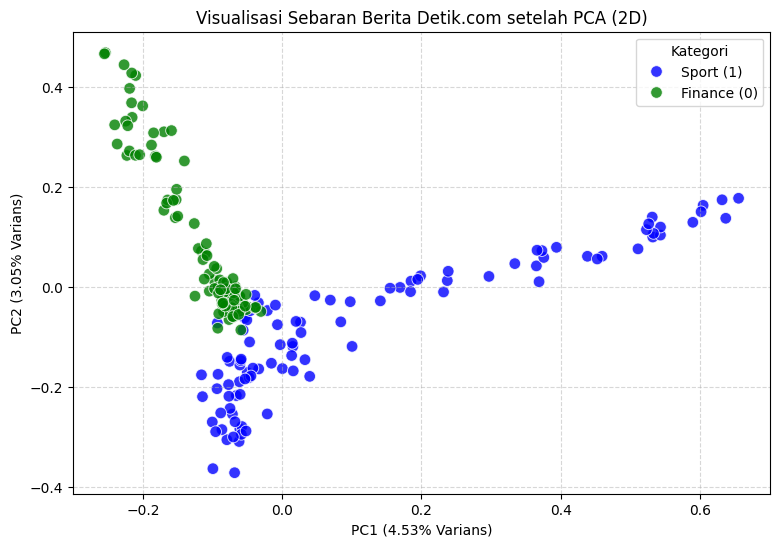

In [20]:
# 1. Buat DataFrame sementara untuk plotting menggunakan 2 komponen pertama
X_pca_2d = X_pca[:, :2]
df_plot = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_plot['label'] = y.map({1: 'Sport (1)', 0: 'Finance (0)'})

# 2. Visualisasi Scatter Plot
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='label', 
    data=df_plot, 
    palette={'Sport (1)': 'blue', 'Finance (0)': 'green'},
    alpha=0.8, s=70
)

plt.title('Visualisasi Sebaran Berita Detik.com setelah PCA (2D)', fontsize=12)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% Varians)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% Varians)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Kategori')
plt.show()

### Pembentukan DataFrame & Ekspor Hasil PCA ke CSV

Menyimpan hasil reduksi dimensi PCA ke dalam file CSV sebagai dataset akhir yang siap digunakan untuk pemodelan Machine Learning (seperti Klasifikasi Naive Bayes, SVM, atau K-NN).

In [21]:
# 1. Buat DataFrame PCA dengan seluruh komponen yang mempertahankan 85% varians
pca_columns = [f'PC{i}' for i in range(1, X_pca.shape[1] + 1)]
df_pca_result = pd.DataFrame(X_pca, columns=pca_columns)

# 2. Sisipkan kembali kolom id dan label di awal
df_pca_result.insert(0, 'label', y)
df_pca_result.insert(0, 'id', df_tfidf['id'])

print("=== TABEL HASIL REDUKSI DIMENSI PCA ===")
display(df_pca_result.head())

# 3. Simpan ke file CSV
df_pca_result.to_csv('detik_pca_results.csv', index=False, encoding='utf-8-sig')

print("\n✅ Tahap Reduksi Dimensi dengan PCA Selesai!")
print("💾 File tersimpan sebagai 'detik_pca_results.csv'")

=== TABEL HASIL REDUKSI DIMENSI PCA ===


,id,label,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC118,PC119,PC120,PC121,PC122,PC123,PC124,PC125,PC126,PC127
0,1,1,-0.053773,-0.061885,-0.000350,-0.058837,0.013994,0.068289,-0.053779,-0.017443,...,0.023696,-0.014662,0.002958,-0.056835,-0.000180,0.010376,-0.022925,0.033728,0.001292,0.005652
1,2,1,-0.075346,-0.148679,-0.016338,0.051595,-0.020576,0.134382,-0.033391,-0.026942,...,0.056043,0.041373,0.076120,-0.027974,-0.031815,-0.066777,-0.020641,-0.094571,-0.030472,-0.017983
2,3,1,-0.050023,-0.170970,0.001593,0.063843,-0.022446,0.094287,-0.009641,0.008280,...,0.127183,-0.003806,-0.025368,-0.079310,0.118688,-0.030169,-0.084056,0.033637,-0.035244,0.024356
3,4,1,-0.065748,-0.217047,-0.014092,0.162086,-0.060429,0.088339,-0.013755,-0.004416,...,0.044703,0.017393,0.122329,-0.009212,0.044905,0.053537,-0.079858,0.009061,-0.074851,0.043998
4,5,1,0.459457,0.061303,0.001194,0.031441,0.042039,-0.046271,0.009134,0.134920,...,-0.062945,-0.046471,0.013460,0.009175,0.031476,0.213290,-0.037325,-0.040529,-0.013520,-0.071726



✅ Tahap Reduksi Dimensi dengan PCA Selesai!
💾 File tersimpan sebagai 'detik_pca_results.csv'
